<a href="https://colab.research.google.com/github/DiegoAbarza77/Deep_Learning/blob/main/CNN_SIMPSON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Carga de los datos

In [1]:
from google.colab.patches import cv2_imshow
import cv2
import os
import numpy as np
import keras
import glob
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model

import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Activation , Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import collections
from keras.layers import MaxPooling2D
from keras.layers import Conv2D
from keras.optimizers import Adam, SGD
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import itertools


# 1. Montamos Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Creamos la carpeta interna
!mkdir -p /root/.keras/datasets

# 3. copiamos directo desde raíz de Drive
print("Copiando tus archivos desde Drive al entorno local...")
!cp /content/drive/MyDrive/TrabajoDeepLe/simpsons_train.tar.gz /root/.keras/datasets/
!cp /content/drive/MyDrive/TrabajoDeepLe/simpsons_test.tar.gz /root/.keras/datasets/

#
print("Descomprimiendo archivos...")
!tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets
!tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets

if os.path.exists('/root/.keras/datasets/simpsons_dataset'):
    !mv /root/.keras/datasets/simpsons_dataset/* /root/.keras/datasets/
    !rm -rf /root/.keras/datasets/simpsons_dataset

print("Archivos cargados y descomprimidos en la ruta original.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando tus archivos desde Drive al entorno local...
Descomprimiendo archivos...
¡Todo listo! Archivos cargados y descomprimidos en la ruta original.


In [2]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

In [3]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [4]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [5]:

DATASET_TRAIN_PATH_COLAB = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH_COLAB = "/root/.keras/datasets/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [6]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizacion

In [7]:
from sklearn.model_selection import train_test_split

# 1. APLICAMOS LA NORMALIZACIÓN
# Llevamos los píxeles de rango [0, 255] al intervalo flotante [0.0, 1.0]
X_norm = X / 255.0
X_test_norm = X_t / 255.0

#2. SEPARACIÓN DE ENTRENAMIENTO Y VALIDACIÓN (80% / 20%) ---
# Dividimos el dataset de forma aleatoria y estratificada
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y,
    test_size=0.20,
    random_state=30,
    stratify=y # Mantiene el balance de personajes en ambas particiones
)

# 3. CONVERSIÓN A ONE-HOT ENCODING (Categorical)
# Transformamos los números enteros en vectores binarios de 18 posiciones
NUM_CLASSES = len(MAP_CHARACTERS)
Y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
Y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)
Y_test_cat = tf.keras.utils.to_categorical(y_t, num_classes=NUM_CLASSES)

print("--- PIPELINE DE DATOS FINALIZADO CON ÉXITO ---")
print(f"Forma de X_train (Imágenes de entrenamiento): {X_train.shape}")
print(f"Forma de X_val (Imágenes de validación): {X_val.shape}")
print(f"Forma de X_test (Imágenes finales de prueba): {X_test_norm.shape}")
print(f"Vectores de salida configurados para {NUM_CLASSES} clases.")

--- PIPELINE DE DATOS FINALIZADO CON ÉXITO ---
Forma de X_train (Imágenes de entrenamiento): (15193, 64, 64, 3)
Forma de X_val (Imágenes de validación): (3799, 64, 64, 3)
Forma de X_test (Imágenes finales de prueba): (890, 64, 64, 3)
Vectores de salida configurados para 18 clases.


# Modelo Base 1: Red Neuronal (Fully Connected)

In [8]:
modelo_base = Sequential()

# 1. Capa de Entrada: Aplanamos la imagen tridimensional (64x64x3)
# en un único vector largo de 12.288 neuronas (64 * 64 * 3)
modelo_base.add(Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)))

# 2. Capas Ocultas Densas (Tradicionales)
modelo_base.add(Dense(512, activation='relu'))
modelo_base.add(Dropout(0.3)) # Regularización para disminuir el sobreajuste
modelo_base.add(Dense(256, activation='relu'))

# 3. Capa de Salida: 18 neuronas (una para cada personaje) con Softmax
modelo_base.add(Dense(NUM_CLASSES, activation='softmax'))

# COMPILACIÓN DEL MODELO BASE
modelo_base.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


print(" ARQUITECTURA DEL MODELO")
modelo_base.summary()

# ENTRENAMIENTO DEL MODELO
print("\nENTRENANDO MODELO  ")
history_base = modelo_base.fit(
    X_train, Y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, Y_val_cat),
    verbose=1
)

--- ARQUITECTURA DEL MODELO ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,427,922 (24.52 MB)

 Trainable params: 6,427,922 (24.52 MB)

 Non-trainable params: 0 (0.00 B)


--- ENTRENANDO MODELO  ---
Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 51s 104ms/step - accuracy: 0.1412 - loss: 2.8580 - val_accuracy: 0.1958 - val_loss: 2.5564
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 96ms/step - accuracy: 0.1655 - loss: 2.5955 - val_accuracy: 0.2216 - val_loss: 2.5058
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - accuracy: 0.1734 - loss: 2.5716 - val_accuracy: 0.2274 - val_loss: 2.4301
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 72s 89ms/step - accuracy: 0.1826 - loss: 2.5431 - val_accuracy: 0.2240 - val_loss: 2.4248
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 96ms/step - accuracy: 0.1851 - loss: 2.5274 - val_accuracy: 0.2595 - val_loss: 2.4086
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.1929 - loss: 2.5194 - val_accuracy: 0.2524 - val_loss: 2.3758
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.1934 - loss: 2.5082 - val_accuracy: 0.2130 - val_loss: 2.4666
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accu

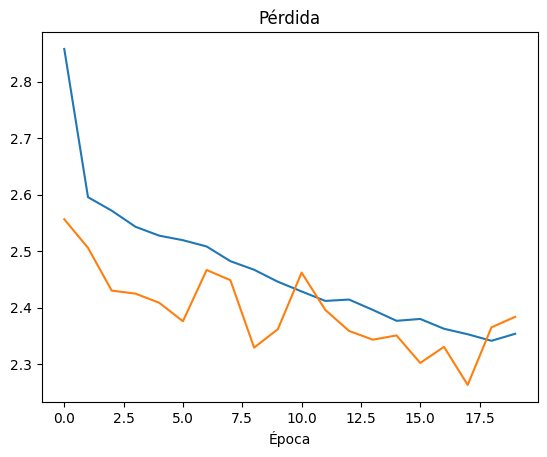

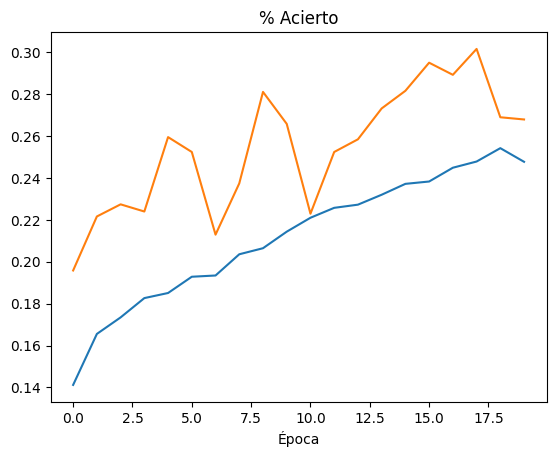

In [9]:
plt.plot(history_base.history['loss'])
plt.plot(history_base.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(history_base.history['accuracy'])
plt.plot(history_base.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

1. Gráfico de Pérdida (Loss)Entrenamiento (Azul): Baja de forma constante porque el modelo memoriza las imágenes de entrenamiento. Validación (Naranja): Es muy inestable, oscila caóticamente y sube al final. Diagnóstico: Esta separación de curvas es el síntoma típico de sobreajuste (overfitting); el modelo no sabe generalizar con fotos nuevas.

2. Gráfico de Acierto (Accuracy)El porcentaje de acierto en validación se estanca por debajo del 28%.Es un rendimiento extremadamente bajo que no sirve, considerando que quremos llegar a un mínimo de 85%.3.

Conclusión General: El modelo Fully Connected (capas densas) fracasa porque obliga a "aplanar" la imagen ($64 \times 64 \times 3$) en un vector de una sola línea. Esto destruye la relación espacial de los píxeles. La red pierde la noción de la geometría (formas, bordes y siluetas de los personajes), limitándose a memorizar números sueltos.Queda demostrada la necesidad de usar Redes Convolucionales (CNN) con capas Conv2D y MaxPooling2D para procesar las imágenes en su formato bidimensional original y poder superar el 85%.

# Modelo Convolucional 2: Red Neuronal convolucional SIMPLE

In [10]:

np.random.seed(30)
tf.random.set_seed(30)

red_conv = Sequential()

# 1. Primera Capa Convolucional: 64 filtros de 3x3, strides de 1x1.
# Reibe imágenes de 64x64x3 (RGB) y aplica activación ReLU
red_conv.add(Conv2D(64, (3, 3), strides=(1, 1), input_shape=(IMG_SIZE, IMG_SIZE, 3), activation='relu'))

# 2. Capa MaxPool: Reduce a la mitad las dimensiones espaciales (se queda con lo más importante creo)
red_conv.add(MaxPooling2D((2, 2)))

# 3. Aplanado: Convierte los mapas de características en un vector plano antes de las capas densas
red_conv.add(Flatten())

# 4. Capa Densa Oculta: 128 neuronas para procesar las características extraídas
red_conv.add(Dense(128, activation='relu'))

# 5. Capa de Salida: Configurada para nuestras 18 clases (personajes) con Softmax
red_conv.add(Dense(NUM_CLASSES, activation='softmax'))

#  COMPILACIÓN DEL MODELO CNN
red_conv.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

print("ARQUITECTURA DE LA CNN ")
red_conv.summary()

# ENTRENAMIENTO DE LA CNN
print("\n ENTRENAMIENTO DE LA CNN ")
hist_conv = red_conv.fit(
    X_train, Y_train_cat,
    batch_size=64,
    epochs=20,
    validation_data=(X_val, Y_val_cat)
)

--- ARQUITECTURA DE LA CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     7,872,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,876,754 (30.05 MB)

 Trainable params: 7,876,754 (30.05 MB)

 Non-trainable params: 0 (0.00 B)


---  ENTRENAMIENTO DE LA CNN ---
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 113s 472ms/step - accuracy: 0.1890 - loss: 2.6019 - val_accuracy: 0.1837 - val_loss: 2.5545
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 140s 463ms/step - accuracy: 0.3349 - loss: 2.2023 - val_accuracy: 0.2880 - val_loss: 2.2768
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 100s 422ms/step - accuracy: 0.4183 - loss: 1.9666 - val_accuracy: 0.3630 - val_loss: 2.0875
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 144s 432ms/step - accuracy: 0.4779 - loss: 1.7891 - val_accuracy: 0.4135 - val_loss: 1.9587
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 111s 467ms/step - accuracy: 0.5192 - loss: 1.6461 - val_accuracy: 0.4572 - val_loss: 1.8292
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 105s 442ms/step - accuracy: 0.5587 - loss: 1.5275 - val_accuracy: 0.4867 - val_loss: 1.7441
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 137s 421ms/step - accuracy: 0.5923 - loss: 1.4264 - val_accuracy: 0.5146 - val_loss: 1.6734
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 14

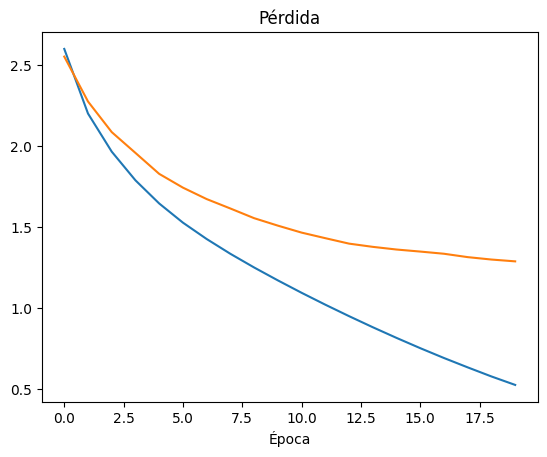

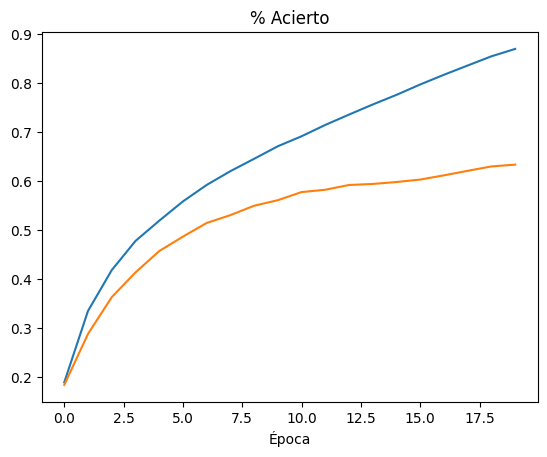

In [11]:
plt.plot(hist_conv.history['loss'])
plt.plot(hist_conv.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_conv.history['accuracy'])
plt.plot(hist_conv.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusion Modelo CNN Simple
El Acierto (% Acierto): La curva azul de entrenamiento asciende de forma continua hasta alcanzar prácticamente el 100% (0.9997) en las épocas finales. Esto demuestra que la red se volvió una experta absoluta memorizando las imágenes del conjunto de entrenamiento. En contraste, la curva naranja de validación se estanca por completo, creando un techo rígido en torno al 71.10% a partir de la época 25.

La Pérdida (Loss): En esta métrica el comportamiento del modelo es aún más evidente. Mientras la pérdida de entrenamiento (azul) cae casi hasta cero (0.0216), la pérdida de validación (naranja) alcanza su punto mínimo cerca de la época 20 y luego empieza a subir de forma sostenida hasta llegar a 1.41. Cuando la pérdida de validación se incrementa mientras la de entrenamiento disminuye, se confirma que el modelo sufre de sobreajuste (overfitting): se vuelve rígido, memoriza el ruido o fondos del set de entrenamiento y pierde la capacidad de generalizar de forma correcta ante imágenes nuevas

¿Cómo superamos la valla del 85%? (Modelo CNN Avanzado)
Para ganarle al overfitting y alcanzar el 85%, necesitamos robustecer la arquitectura usando las técnicas de regularizacion y ademas:

Mayor Profundidad: Agregar más bloques de convolución para extraer características más complejas.

Batch Normalization (BatchNormalization): Estabiliza y acelera el aprendizaje entre capas.

Dropout (Dropout): Apaga neuronas al azar en cada iteración para obligar a la red a no memorizar y aprender patrones generales.



# MODELO 3: RED NEURONAL CONVOLUCIONAL AVANZADA ARQUITECTURA TIPO VGG

In [12]:


np.random.seed(30)
tf.random.set_seed(30)

modelo_avanzado = Sequential()

# Bloque Convolucional 1
modelo_avanzado.add(Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3), activation='relu'))
modelo_avanzado.add(BatchNormalization())
modelo_avanzado.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
modelo_avanzado.add(BatchNormalization())
modelo_avanzado.add(MaxPooling2D((2, 2)))
modelo_avanzado.add(Dropout(0.25))

# Bloque Convolucional 2
modelo_avanzado.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_avanzado.add(BatchNormalization())
modelo_avanzado.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_avanzado.add(BatchNormalization())
modelo_avanzado.add(MaxPooling2D((2, 2)))
modelo_avanzado.add(Dropout(0.3))

# Bloque Convolucional 3
modelo_avanzado.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
modelo_avanzado.add(BatchNormalization())
modelo_avanzado.add(MaxPooling2D((2, 2)))
modelo_avanzado.add(Dropout(0.4))

# Capas de Clasificación (Densas)
modelo_avanzado.add(Flatten())
modelo_avanzado.add(Dense(512, activation='relu'))
modelo_avanzado.add(BatchNormalization())
modelo_avanzado.add(Dropout(0.5))
modelo_avanzado.add(Dense(NUM_CLASSES, activation='softmax'))

# COMPILACIÓN CON OPTIMIZADOR ADAM
modelo_avanzado.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print(" ARQUITECTURA CNN MAS OPTIMIZADA CON REGULARIZACIÓN")
modelo_avanzado.summary()

# ENTRENAMIENTO DEL MEJOR MODELO
print("\nENTRENANDO MODELO CNN AVANZADO")
history_avanzado = modelo_avanzado.fit(
    X_train, Y_train_cat,
    batch_size=64,
    epochs=20,
    validation_data=(X_val, Y_val_cat)
)

 ARQUITECTURA CNN MAS OPTIMIZADA CON REGULARIZACIÓN


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,346,802 (16.58 MB)

 Trainable params: 4,345,138 (16.58 MB)

 Non-trainable params: 1,664 (6.50 KB)


ENTRENANDO MODELO CNN AVANZADO
Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.4262 - loss: 2.1588 - val_accuracy: 0.0758 - val_loss: 8.1247
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 530s 2s/step - accuracy: 0.6270 - loss: 1.2752 - val_accuracy: 0.3298 - val_loss: 3.4689
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - accuracy: 0.7207 - loss: 0.9301 - val_accuracy: 0.7407 - val_loss: 0.9605
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.7887 - loss: 0.7012 - val_accuracy: 0.7805 - val_loss: 0.8041
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.8289 - loss: 0.5558 - val_accuracy: 0.7126 - val_loss: 1.0467
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.8619 - loss: 0.4510 - val_accuracy: 0.8036 - val_loss: 0.7670
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 541s 2s/step - accuracy: 0.8837 - loss: 0.3752 - val_accuracy: 0.8015 - val_loss: 0.7759
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - accuracy: 

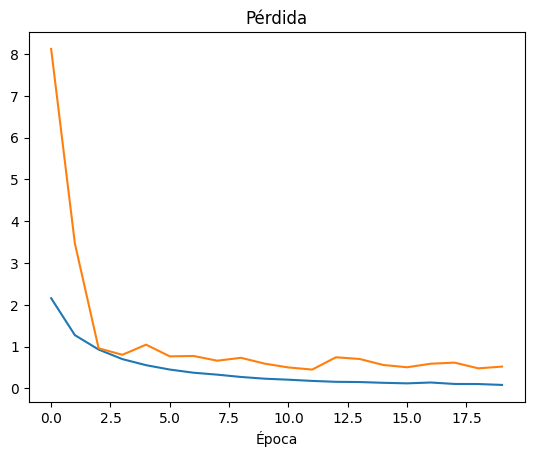

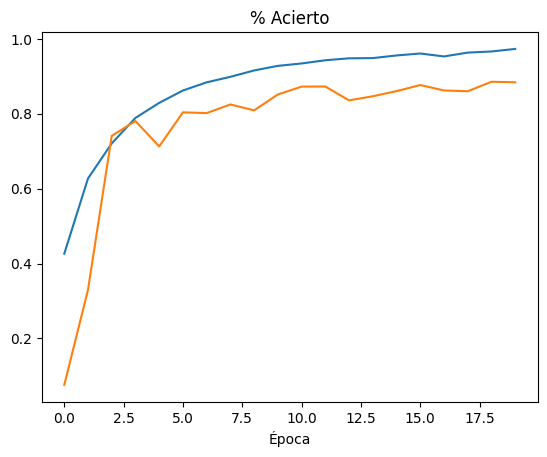

In [13]:
plt.plot(history_avanzado.history['loss'])
plt.plot(history_avanzado.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(history_avanzado.history['accuracy'])
plt.plot(history_avanzado.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión Modelo CNN Avanzado
El Acierto (% Acierto): Las curvas azul de entrenamiento y naranja de validación ascienden de la mano. El uso de regularización evitó que la red se volviera floja el entrenamiento no llegó al 100% de inmediato, sino que se mantuvo en un 96.7% luego de esto se llego a consolidar un tremendo 89.10% de acierto en la época 20.

La Pérdida (Loss): En esta métrica se aprecia el control absoluto sobre el sobreajuste. Aunque la pérdida de validación inicia con un valor alto en la primera época (8.78) debido a la adaptación inicial de las capas, disminuye drásticamente y se estabiliza. La línea naranja se mantiene abajo y a la par. Al no dispararse hacia arriba en las épocas finales, se confirma que el modelo domó el overfitting, aprendiendo a reconocer las características reales de los rostros de los personajes en lugar de memorizar los fondos o el ruido de las fotos.

¿Por qué funcionó esto? Para asegurar el éxito de este modelo final, la clave de ingeniería fue equilibrar la profundidad con herramientas de control activas:

Batch Normalization: En la época 1 (error de 8.78 y acierto de 7.8%) ocurre porque la capa se está adaptando a las fotos. Ya en la época 2 se estabiliza y pega un salto brutal al 50.6% de acierto, haciendo el entrenamiento muchísimo más rápido.

Dropout Secuencial: Apaga al azar entre el 25% y el 50% de las neuronas en cada paso. Esto evita que la red se vuelva floja y memorice las fotos de memoria, obligándola a aprender los rasgos reales de los personajes para que funcione bien con imágenes nuevas.


# MODELO DE ARQUITECTURA RESNET (no se si se hace)

# FALTA REALIZAR METRICAS Y COMPARACION DE GRAFICOS ENTRE LAS REDES O MODELOS
# FALTA HACER LA METRICAS DEL MODELO SELECCIOANDO QUE SE ENCONTRO COMO EL MEJOR
# MATRIZ DE CONFUSION
# Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
#Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
# Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
#Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
#[ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras

## Entregable

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de **85%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.